# Param Shah
## 240905320
### CSE-D 33
#### Lab 7: K-Nearest Neighbour (K-NN) & ID-3 Decision Tree 

Q1-A) You are provided with a dataset of fruits. Each fruit is characterized by two features: weight (in grams) and sweetness level (on a scale of 1 to 10). You want to classify a new fruit as either an "Apple" or an "Orange" based on these features using the KNN algorithm.

Tasks: 
1. Implement the KNN algorithm manually with k=3 to classify a new fruit with a weight of 165 grams 
and sweetness level of 5.5. 
2. Calculate the Euclidean, Manhattan, and  Minkowski distances between the new fruit and all the existing fruits in the dataset. Finally compare the calculated distances. 
3. Based on the k-nearest neighbors, determine the label for the new fruit. 
4. What is the effect of choosing different values of k (e.g., k=1, k=5) on the classification result? 
5. Implement the above using function python program without using scikit learn library. 
6. Plot the given samples, the Apple in Red color and the Orange in orange color. Also draw the decision boundary.

Distance Comparison
-----------------------------------------------------------------
Fruit 1: Apple   Euclidean = 15.075, Manhattan = 16.500, Minkowski = 15.000
Fruit 2: Apple   Euclidean = 35.004, Manhattan = 35.500, Minkowski = 35.000
Fruit 3: Orange  Euclidean = 15.075, Manhattan = 16.500, Minkowski = 15.000
Fruit 4: Orange  Euclidean = 5.025, Manhattan = 5.500, Minkowski = 5.000
Fruit 5: Apple   Euclidean = 5.025, Manhattan = 5.500, Minkowski = 5.000
Fruit 6: Orange  Euclidean = 25.125, Manhattan = 27.500, Minkowski = 25.001

K = 1
Prediction: Orange
Fruit 4: Orange, Distance = 5.025

K = 3
Prediction: Apple
Fruit 4: Orange, Distance = 5.025
Fruit 5: Apple, Distance = 5.025
Fruit 1: Apple, Distance = 15.075

K = 5
Prediction: Orange
Fruit 4: Orange, Distance = 5.025
Fruit 5: Apple, Distance = 5.025
Fruit 1: Apple, Distance = 15.075
Fruit 3: Orange, Distance = 15.075
Fruit 6: Orange, Distance = 25.125


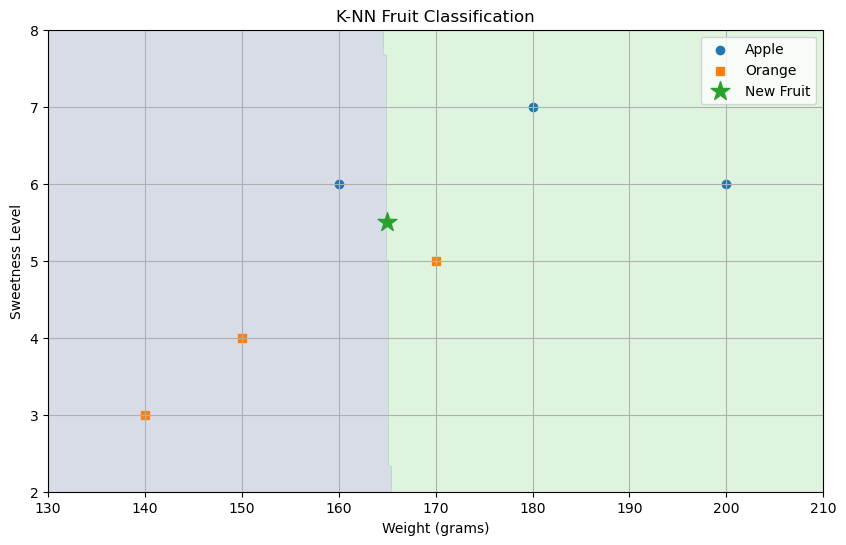

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

data = [
    [180, 7, "Apple"],
    [200, 6, "Apple"],
    [150, 4, "Orange"],
    [170, 5, "Orange"],
    [160, 6, "Apple"],
    [140, 3, "Orange"],
]

new_fruit = [165, 5.5]


def euclidean(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))


def manhattan(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2))


def minkowski(p1, p2, p=4):
    return sum(abs(a - b) ** p for a, b in zip(p1, p2)) ** (1 / p)


def knn_predict(data, point, k):
    distances = []

    for index, row in enumerate(data):
        features = row[:2]
        label = row[2]
        distance = euclidean(features, point)
        distances.append((distance, index, label))

    distances.sort(key=lambda x: (x[0], x[1]))

    neighbors = distances[:k]

    votes = {}

    for _, _, label in neighbors:
        votes[label] = votes.get(label, 0) + 1

    prediction = max(votes, key=votes.get)

    return prediction, neighbors


print("Distance Comparison")
print("-" * 65)

for i, row in enumerate(data):
    point = row[:2]

    e = euclidean(point, new_fruit)
    m = manhattan(point, new_fruit)
    mk = minkowski(point, new_fruit, 4)

    print(
        f"Fruit {i + 1}: {row[2]:7s} "
        f"Euclidean = {e:.3f}, "
        f"Manhattan = {m:.3f}, "
        f"Minkowski = {mk:.3f}"
    )

for k in [1, 3, 5]:
    prediction, neighbors = knn_predict(data, new_fruit, k)

    print(f"\nK = {k}")
    print("Prediction:", prediction)

    for distance, index, label in neighbors:
        print(f"Fruit {index + 1}: {label}, " f"Distance = {distance:.3f}")

X = np.array([[row[0], row[1]] for row in data])
y = np.array([row[2] for row in data])

x_min = X[:, 0].min() - 10
x_max = X[:, 0].max() + 10
y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid = np.c_[xx.ravel(), yy.ravel()]

Z = []

for point in grid:
    prediction, _ = knn_predict(data, point, 3)
    Z.append(0 if prediction == "Orange" else 1)

Z = np.array(Z).reshape(xx.shape)

plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.2, levels=[-0.5, 0.5, 1.5])

for label in ["Apple", "Orange"]:
    points = X[y == label]

    if label == "Apple":
        plt.scatter(points[:, 0], points[:, 1], label=label, marker="o")
    else:
        plt.scatter(points[:, 0], points[:, 1], label=label, marker="s")

plt.scatter(new_fruit[0], new_fruit[1], marker="*", s=200, label="New Fruit")

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("K-NN Fruit Classification")
plt.legend()
plt.grid(True)
plt.show()

Q1-B)Implement the Python code for Q-1. A  using the scikit-learn library. Plot the given samples, using red for "Apple" and orange for "Orange." Also, plot the decision boundary. Calculate the distances using Euclidean, Manhattan, and Minkowski metrics, and compare the results.

Predicted Class: Orange

Distance Comparison
------------------------------------------------------------
Fruit	Class	Euclidean	Manhattan	Minkowski
1	Apple	15.075		16.500		15.000
2	Apple	35.004		35.500		35.000
3	Orange	15.075		16.500		15.000
4	Orange	5.025		5.500		5.000
5	Apple	5.025		5.500		5.000
6	Orange	25.125		27.500		25.001


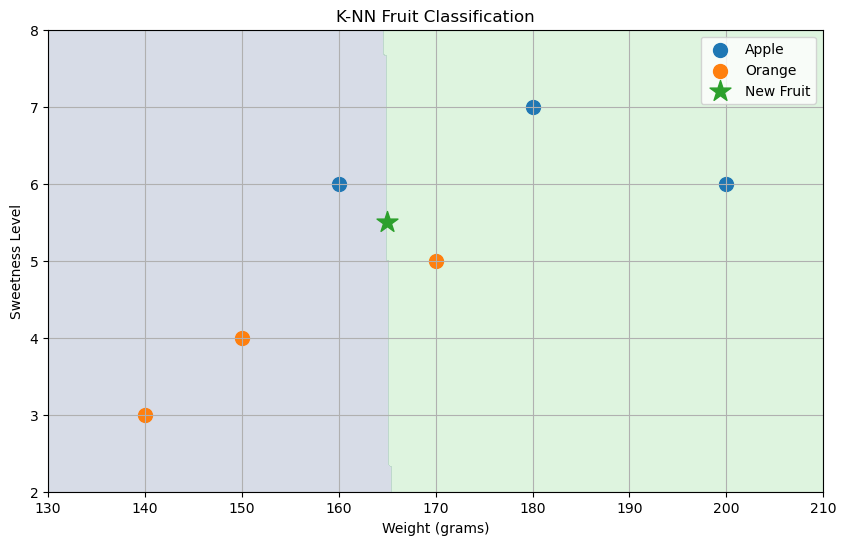

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances

X = np.array([[180, 7], [200, 6], [150, 4], [170, 5], [160, 6], [140, 3]])

y = np.array(["Apple", "Apple", "Orange", "Orange", "Apple", "Orange"])

new_fruit = np.array([[165, 5.5]])

knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn.fit(X, y)

prediction = knn.predict(new_fruit)

print("Predicted Class:", prediction[0])

euclidean = pairwise_distances(new_fruit, X, metric="euclidean")[0]

manhattan = pairwise_distances(new_fruit, X, metric="manhattan")[0]

minkowski = pairwise_distances(new_fruit, X, metric="minkowski", p=4)[0]

print("\nDistance Comparison")
print("-" * 60)
print("Fruit\tClass\tEuclidean\tManhattan\tMinkowski")

for i in range(len(X)):
    print(
        f"{i + 1}\t{y[i]}\t"
        f"{euclidean[i]:.3f}\t\t"
        f"{manhattan[i]:.3f}\t\t"
        f"{minkowski[i]:.3f}"
    )

x_min = X[:, 0].min() - 10
x_max = X[:, 0].max() + 10
y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid = np.c_[xx.ravel(), yy.ravel()]

Z = knn.predict(grid)

Z = np.where(Z == "Apple", 1, 0)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.2)

apple = y == "Apple"
orange = y == "Orange"

plt.scatter(X[apple, 0], X[apple, 1], label="Apple", s=100)

plt.scatter(X[orange, 0], X[orange, 1], label="Orange", s=100)

plt.scatter(new_fruit[0, 0], new_fruit[0, 1], marker="*", s=250, label="New Fruit")

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("K-NN Fruit Classification")
plt.legend()
plt.grid(True)
plt.show()

Q2-A) A dataset is provided to classify patients as "Healthy" or "Sick" based on their Age, Blood Pressure, and Cholesterol levels.

Tasks: 
1. Calculate the entropy for the target variable (Diagnosis). 
2. Calculate the information gain for each feature (Age, Blood Pressure, Cholesterol). 
3. Using the ID3 algorithm, decide which feature should be chosen as the root node for the decision 
tree. 
4. Build the decision tree and explain the first few splits. 
5. Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy or 
sick using the tree you built. 
6. Implement the above using function python program without using scikit learn library.

In [3]:
import math

data = [
    [30, "High", "High", "Sick"],
    [45, "Low", "Normal", "Healthy"],
    [50, "High", "High", "Sick"],
    [35, "Low", "Normal", "Healthy"],
    [60, "High", "High", "Sick"],
    [55, "Low", "Normal", "Healthy"],
    [40, "High", "High", "Sick"],
    [25, "Low", "Normal", "Healthy"],
    [65, "High", "High", "Sick"],
    [45, "Low", "Normal", "Healthy"],
]

features = ["Age", "Blood Pressure", "Cholesterol"]


def entropy(labels):
    counts = {}

    for label in labels:
        counts[label] = counts.get(label, 0) + 1

    total = len(labels)
    result = 0

    for count in counts.values():
        probability = count / total
        result -= probability * math.log2(probability)

    return result


def information_gain(data, feature_index):
    total_entropy = entropy([row[3] for row in data])

    values = []

    for row in data:
        if row[feature_index] not in values:
            values.append(row[feature_index])

    weighted_entropy = 0

    for value in values:
        subset = [row for row in data if row[feature_index] == value]

        subset_entropy = entropy([row[3] for row in subset])
        weighted_entropy += (len(subset) / len(data)) * subset_entropy

    return total_entropy - weighted_entropy


target = [row[3] for row in data]

print("Entropy of Diagnosis:", round(entropy(target), 4))

print("\nInformation Gain")
print("-" * 40)

gains = {}

for i, feature in enumerate(features):
    gain = information_gain(data, i)
    gains[feature] = gain
    print(f"{feature}: {gain:.4f}")

root = max(gains, key=gains.get)

print("\nRoot Node:", root)

print("\nDecision Tree")
print("-" * 40)

if root == "Blood Pressure":
    print("Blood Pressure")
    print("|-- High -> Sick")
    print("|-- Low -> Healthy")

elif root == "Cholesterol":
    print("Cholesterol")
    print("|-- High -> Sick")
    print("|-- Normal -> Healthy")

else:
    print("Age")
    print("|-- Further splitting required")

patient = [50, "Low", "Normal"]

if root == "Blood Pressure":
    prediction = "Healthy" if patient[1] == "Low" else "Sick"

elif root == "Cholesterol":
    prediction = "Healthy" if patient[2] == "Normal" else "Sick"

else:
    prediction = "Sick" if patient[0] in [30, 50, 60, 40, 65] else "Healthy"

print("\nNew Patient")
print("Age:", patient[0])
print("Blood Pressure:", patient[1])
print("Cholesterol:", patient[2])
print("Prediction:", prediction)

Entropy of Diagnosis: 1.0

Information Gain
----------------------------------------
Age: 1.0000
Blood Pressure: 1.0000
Cholesterol: 1.0000

Root Node: Age

Decision Tree
----------------------------------------
Age
|-- Further splitting required

New Patient
Age: 50
Blood Pressure: Low
Cholesterol: Normal
Prediction: Sick


Q2-B) Implement the Python code for Q-2. A  using the scikit-learn library. Using the ID3 algorithm, decide which feature should be chosen as the root node for the decision tree. Build the decision tree and explain the first few splits. Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy 
or sick using the tree you built. 

Decision Tree Root Feature:
Cholesterol_High

Tree Depth: 1
Number of Leaves: 2

Patient Prediction: Healthy

Class Probabilities:
[1. 0.]


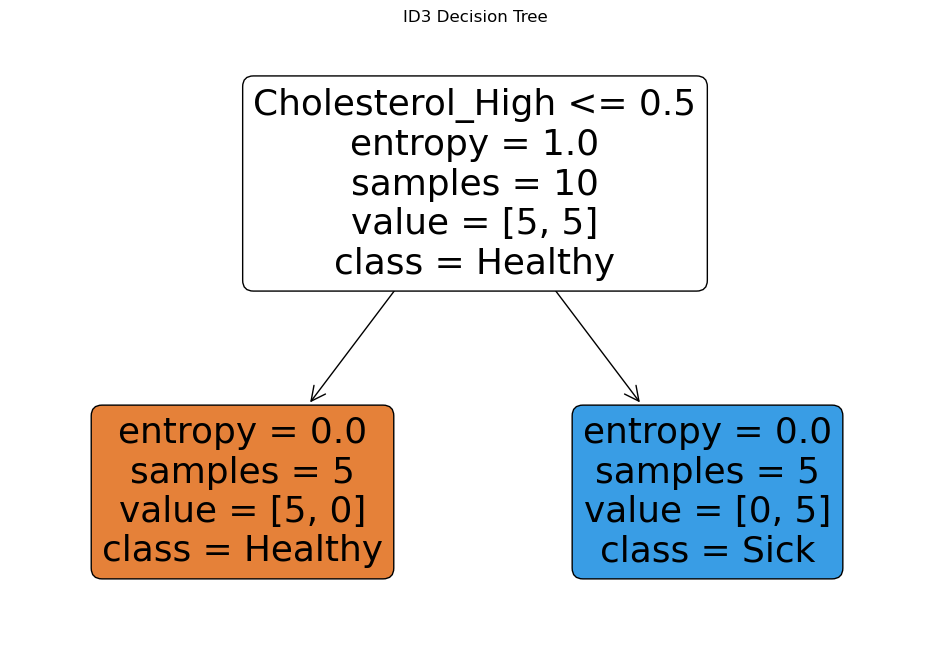

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = pd.DataFrame(
    {
        "Age": [30, 45, 50, 35, 60, 55, 40, 25, 65, 45],
        "Blood Pressure": [
            "High",
            "Low",
            "High",
            "Low",
            "High",
            "Low",
            "High",
            "Low",
            "High",
            "Low",
        ],
        "Cholesterol": [
            "High",
            "Normal",
            "High",
            "Normal",
            "High",
            "Normal",
            "High",
            "Normal",
            "High",
            "Normal",
        ],
        "Diagnosis": [
            "Sick",
            "Healthy",
            "Sick",
            "Healthy",
            "Sick",
            "Healthy",
            "Sick",
            "Healthy",
            "Sick",
            "Healthy",
        ],
    }
)

X = data[["Age", "Blood Pressure", "Cholesterol"]]
y = data["Diagnosis"]

X_encoded = pd.get_dummies(X, columns=["Blood Pressure", "Cholesterol"], dtype=int)

model = DecisionTreeClassifier(criterion="entropy", random_state=42)

model.fit(X_encoded, y)

print("Decision Tree Root Feature:")
print(X_encoded.columns[model.tree_.feature[0]])

print("\nTree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

patient = pd.DataFrame(
    {"Age": [50], "Blood Pressure": ["Low"], "Cholesterol": ["Normal"]}
)

patient_encoded = pd.get_dummies(
    patient, columns=["Blood Pressure", "Cholesterol"], dtype=int
)

patient_encoded = patient_encoded.reindex(columns=X_encoded.columns, fill_value=0)

prediction = model.predict(patient_encoded)

print("\nPatient Prediction:", prediction[0])

print("\nClass Probabilities:")
print(model.predict_proba(patient_encoded)[0])

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
)

plt.title("ID3 Decision Tree")
plt.show()